# Imports



In [5]:
# Import all libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['figure.dpi'] = 100

print(f"All libraries imported successfully!")
print(f"pandas version:  {pd.__version__}")
print(f"seaborn version: {sns.__version__}")

All libraries imported successfully!
pandas version:  3.0.3
seaborn version: 0.13.2


# Load The Data

In [6]:
# Load the CSV file
# use../ to "go up one folder" out of notebooks/ and into churn-prediction/
# then /data/ points to the data subfolder

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset loaded successfully!")
print(f"Rows (customers):   {df.shape[0]:,}")
print(f"Columns (features): {df.shape[1]}")
print(f"Total cells:        {df.shape[0] * df.shape[1]:,}")

Dataset loaded successfully!
Rows (customers):   7,043
Columns (features): 21
Total cells:        147,903


# Preview the Data

In [10]:
# Look at the first 5 rows
print(f"First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Column Types

In [9]:
# See the data type of every column

print(f"{'Column':<25} {'Data Type'}")
print(f"{'-'*40}")
for col, dtype in df.dtypes.items():
    print(f"{col:<25} {dtype}")
print(f"\nTotal columns: {len(df.columns)}")

Column                    Data Type
----------------------------------------
customerID                str
gender                    str
SeniorCitizen             int64
Partner                   str
Dependents                str
tenure                    int64
PhoneService              str
MultipleLines             str
InternetService           str
OnlineSecurity            str
OnlineBackup              str
DeviceProtection          str
TechSupport               str
StreamingTV               str
StreamingMovies           str
Contract                  str
PaperlessBilling          str
PaymentMethod             str
MonthlyCharges            float64
TotalCharges              str
Churn                     str

Total columns: 21


# Check for Missing Values

In [12]:
# Count missing (empty) values in every column

missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) == 0:
    print(f"No missing values found in any column.")
else:
    print(f"Columns with missing values:")
    for col, count in missing_cols.items():
        pct = count / len(df) * 100
        print(f"  {col:<25} {count:>5} missing ({pct:.1f}%)")

No missing values found in any column.


# Fix the TotalCharges Column

In [13]:
# Fix the hidden data quality problem
# TotalCharges is stored as text because some rows have a blank space " "
# instead of a real number — this happens for brand-new customers with $0 charges

print(f"TotalCharges dtype BEFORE fix: {df['TotalCharges'].dtype}")

# errors='coerce' → if conversion fails, set the value to NaN (blank)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

nan_count = df['TotalCharges'].isnull().sum()
print(f"TotalCharges dtype AFTER fix:  {df['TotalCharges'].dtype}")
print(f"NaN values created:            {nan_count} (brand-new customers with $0 charges)")

df = df.dropna(subset=['TotalCharges'])
print(f"Shape after dropping blank rows: {df.shape[0]:,} rows × {df.shape[1]} columns")

TotalCharges dtype BEFORE fix: str
TotalCharges dtype AFTER fix:  float64
NaN values created:            11 (brand-new customers with $0 charges)
Shape after dropping blank rows: 7,032 rows × 21 columns


# Explore the Target Variable

In [ ]:
# Churn is the "target variable" — what we're trying to predict
# Churn = Yes means the customer cancelled their subscription
# "Yes" → customer left/cancelled
# "No" → customer stayed

# count how many times each value appears in the Churn column.
churn_counts = df['Churn'].value_counts()
print(f"\nchrun counts:{churn_counts}")

# This calculates percentages instead of raw counts.
# normalize=True -> Divided each count by the total number of rows.
churn_pcts   = df['Churn'].value_counts(normalize=True) * 100
print(f"\nchrun percents:{churn_pcts}\n\n")


print(f"{'='*45}")
print(f"CHURN DISTRIBUTION")
print(f"{'='*45}")
for label in churn_counts.index:
    count = churn_counts[label]
    pct   = churn_pcts[label]
    print(f"  {label:<6} → {count:>5,} customers  ({pct:.1f}%)")

ratio = churn_counts['No'] / churn_counts['Yes']
print(f"\nIMBALANCE RATIO: {ratio:.1f}:1")
print(f"For every 1 churner there are {ratio:.1f} customers who stay.")
print(f"\nKEY INSIGHT: A model that ALWAYS predicts 'stay' would be")
print(f"{churn_pcts['No']:.1f}% accurate — but would catch ZERO actual churners.")
print(f"We need to  fix this. can us SMOTE.")


chrun counts:Churn
No     5163
Yes    1869
Name: count, dtype: int64

chrun percents:Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


CHURN DISTRIBUTION
  No     → 5,163 customers  (73.4%)
  Yes    → 1,869 customers  (26.6%)

IMBALANCE RATIO: 2.8:1
For every 1 churner there are 2.8 customers who stay.

KEY INSIGHT: A model that ALWAYS predicts 'stay' would be
73.4% accurate — but would catch ZERO actual churners.
We fix this in Phase 3 using SMOTE.


# Churn Distribution Chart


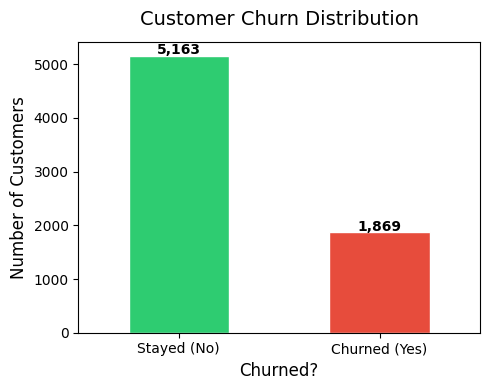

Chart saved → outputs/churn_distribution.png


In [17]:
# Visualise the churn imbalance

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#2ecc71', '#e74c3c']
churn_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')

ax.set_title('Customer Churn Distribution', fontsize=14, pad=12)
ax.set_xlabel('Churned?', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_xticklabels(['Stayed (No)', 'Churned (Yes)'], rotation=0)

for i, (label, count) in enumerate(churn_counts.items()):
    ax.text(i, count + 30, f"{count:,}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved → outputs/churn_distribution.png")

# Churn by Contract Type


Contract Type               Churn Rate
--------------------------------------
Month-to-month                42.7%  █████████████████████
One year                      11.3%  █████
Two year                       2.8%  █


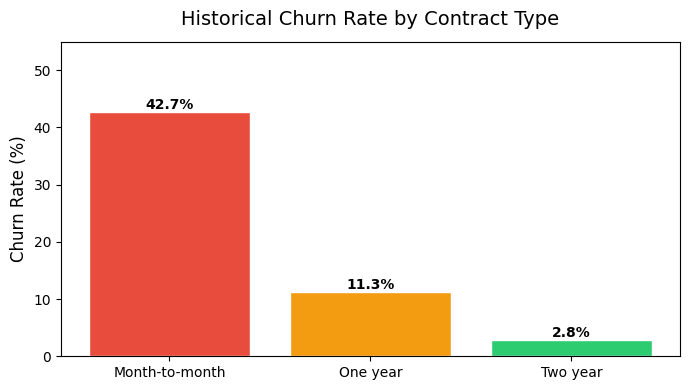

Chart saved → outputs/contract_churn.png


In [18]:
# Which contract type has the highest churn rate?

contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate (%)']

print(f"{'Contract Type':<25} {'Churn Rate':>12}")
print(f"{'-'*38}")
for _, row in contract_churn.iterrows():
    bar = '█' * int(row['Churn Rate (%)'] / 2)
    print(f"{row['Contract']:<25} {row['Churn Rate (%)']:>8.1f}%  {bar}")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(contract_churn['Contract'], contract_churn['Churn Rate (%)'],
              color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
for bar, val in zip(bars, contract_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha='center', fontweight='bold')

ax.set_title('Historical Churn Rate by Contract Type', fontsize=14, pad=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_ylim(0, 55)
plt.tight_layout()
plt.savefig('../outputs/contract_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved → outputs/contract_churn.png")

# Tenure Distribution


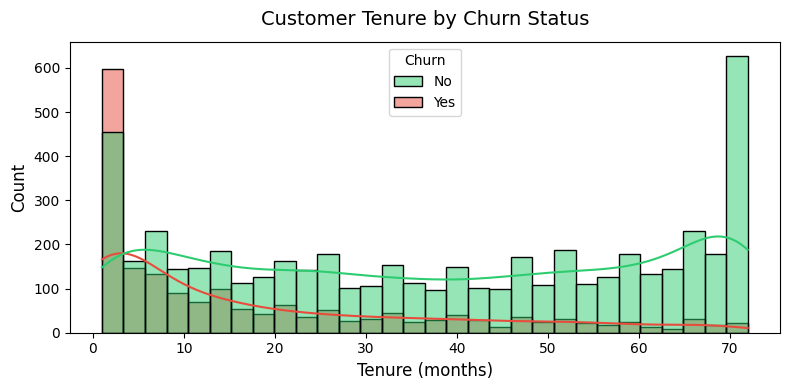

Average tenure — Churned customers: 18.0 months
Average tenure — Stayed customers:  37.7 months
Churners leave 19.7 months earlier on average.
Chart saved → outputs/tenure_churn.png


In [19]:
# How long customers stay before churning

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True,
             palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=ax)
ax.set_title('Customer Tenure by Churn Status', fontsize=14, pad=12)
ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()

avg_churn  = df[df['Churn'] == 'Yes']['tenure'].mean()
avg_stayed = df[df['Churn'] == 'No']['tenure'].mean()
print(f"Average tenure — Churned customers: {avg_churn:.1f} months")
print(f"Average tenure — Stayed customers:  {avg_stayed:.1f} months")
print(f"Churners leave {avg_stayed - avg_churn:.1f} months earlier on average.")
print(f"Chart saved → outputs/tenure_churn.png")

# Monthly Charges vs Churn

/var/folders/j5/g8yxs2nn1933zjsrjmzm69z80000gn/T/ipykernel_16969/3152663678.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
/var/folders/j5/g8yxs2nn1933zjsrjmzm69z80000gn/T/ipykernel_16969/3152663678.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Stayed', 'Churned'])
/var/folders/j5/g8yxs2nn1933zjsrjmzm69z80000gn/T/ipykernel_16969/3152663678.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='TotalCharges',
/var/folders/j5/g8yxs2nn1933zjsrjmzm69z80000gn/T/ipykernel_16969/3152663678.py:13: UserWarning: set_tick

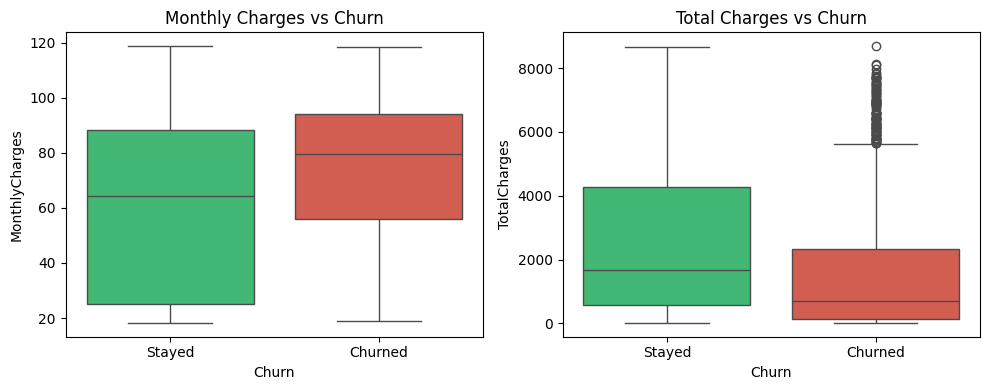

Avg monthly charge — Churned: $74.44
Avg monthly charge — Stayed:  $61.31
Churners pay $13.13/month MORE on average.
Chart saved → outputs/charges_churn.png


In [20]:
# Do higher-paying customers churn more?

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[0])
axes[0].set_title('Monthly Charges vs Churn')
axes[0].set_xticklabels(['Stayed', 'Churned'])

sns.boxplot(data=df, x='Churn', y='TotalCharges',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Total Charges vs Churn')
axes[1].set_xticklabels(['Stayed', 'Churned'])

plt.tight_layout()
plt.savefig('../outputs/charges_churn.png', dpi=150, bbox_inches='tight')
plt.show()

avg_monthly_churn  = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
avg_monthly_stayed = df[df['Churn'] == 'No']['MonthlyCharges'].mean()
print(f"Avg monthly charge — Churned: ${avg_monthly_churn:.2f}")
print(f"Avg monthly charge — Stayed:  ${avg_monthly_stayed:.2f}")
print(f"Churners pay ${avg_monthly_churn - avg_monthly_stayed:.2f}/month MORE on average.")
print(f"Chart saved → outputs/charges_churn.png")

# Summary and Save Cleaned Data

In [21]:
# Full summary then save cleaned data for the next notebook

total      = len(df)
churned    = (df['Churn'] == 'Yes').sum()
churn_rate = churned / total * 100

print(f"{'='*50}")
print(f"EXPLORATION SUMMARY")
print(f"{'='*50}")
print(f"Total customers:        {total:,}")
print(f"Customers who churned:  {churned:,} ({churn_rate:.1f}%)")
print(f"Customers who stayed:   {total - churned:,} ({100 - churn_rate:.1f}%)")
print(f"Average tenure:         {df['tenure'].mean():.1f} months")
print(f"Avg monthly charge:     ${df['MonthlyCharges'].mean():.2f}")
print(f"Avg total charges:      ${df['TotalCharges'].mean():,.2f}")

print(f"\nChurn rate by contract type:")
for contract, rate in df.groupby('Contract')['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100).items():
    print(f"  {contract:<22} {rate:.1f}%")

print(f"\nChurn rate by payment method:")
for method, rate in df.groupby('PaymentMethod')['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100).items():
    print(f"  {method:<35} {rate:.1f}%")

df.to_csv('../data/cleaned_churn.csv', index=False)
print(f"\nCleaned data saved → data/cleaned_churn.csv")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

EXPLORATION SUMMARY
Total customers:        7,032
Customers who churned:  1,869 (26.6%)
Customers who stayed:   5,163 (73.4%)
Average tenure:         32.4 months
Avg monthly charge:     $64.80
Avg total charges:      $2,283.30

Churn rate by contract type:
  Month-to-month         42.7%
  One year               11.3%
  Two year               2.8%

Churn rate by payment method:
  Bank transfer (automatic)           16.7%
  Credit card (automatic)             15.3%
  Electronic check                    45.3%
  Mailed check                        19.2%

Cleaned data saved → data/cleaned_churn.csv
Shape: 7,032 rows × 21 columns
